<a href="https://colab.research.google.com/github/ssurapaneni34/bmi712/blob/main/progress_report_LUNG_UNIv1LungCancer_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================================
# End-to-end: extract UNI v1 embeddings for all lung cancer
# samples in HEST1k, saving features to Google Drive
# ============================================================

# ---------- 0. Mount Google Drive ----------
from google.colab import drive
drive.mount('/content/drive')

# ---------- 1. Imports & auth ----------
import pandas as pd
import torch, timm, h5py, numpy as np
from torchvision import transforms
from huggingface_hub import login, snapshot_download, hf_hub_download
from pathlib import Path
from tqdm import tqdm
import os
login(token=HF_TOKEN)  # needs access to MahmoodLab/hest AND MahmoodLab/UNI

# ---------- 2. Find LUNG cancer sample IDs ----------
meta_df = pd.read_csv("hf://datasets/MahmoodLab/hest/HEST_v1_3_0.csv")
lung = meta_df[meta_df['organ'] == 'Lung']
lung_cancer = lung[lung['disease_state'] == 'Cancer']
print(f"Cancer-only lung samples: {len(lung_cancer)}")

ids = lung_cancer['id'].tolist()


print(meta_df['organ'].value_counts())
print(meta_df['disease_state'].value_counts())
print(meta_df.columns.tolist())

print(lung_cancer.columns.tolist())
# look for columns like: patient, donor, case_id, subject_id, bcr_patient_barcode
print(lung_cancer.head())
print(f"n samples: {len(lung_cancer)}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Cancer-only lung samples: 11
organ
Spinal cord       318
Brain             214
Breast            140
Bowel              95
Skin               88
Lung               72
Kidney             72
Heart              70
Prostate           63
Liver              37
Uterus             24
Eye                10
Bone               10
Muscle             10
Ovary              10
Pancreas            9
Lymphoid            8
Cervix              6
Bladder             6
Lymph node          5
Embryo              3
Lung/Brain          2
Kidney/Brain        1
Whole organism      1
Placenta            1
Other               1
Name: count, dtype: int64
disease_state
Diseased                       454
Cancer                         398
Healthy                        359
Treated                         53
Tumor                            7
Genetically modified             4
Cancer/Genetically modified      1
Name: count, dtype: int64
['dataset_title', 'id', 'image_filename', 'organ', 'disease_state', 'oncotree_code

In [ ]:

# ---------- 3. Load UNI v1 ----------
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

ckpt = hf_hub_download("MahmoodLab/UNI", filename="pytorch_model.bin")
model = timm.create_model(
    "vit_large_patch16_224", img_size=224, patch_size=16,
    init_values=1e-5, num_classes=0, dynamic_img_size=True,
)
model.load_state_dict(torch.load(ckpt, map_location="cpu"), strict=True)
model.eval().to(device)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

# ---------- 4. Set up dirs ----------
# Raw patches → ephemeral Colab disk (deleted after each sample)
# UNI features → Google Drive (persistent)
patch_dir = Path("hest_data/patches")
patch_dir.mkdir(parents=True, exist_ok=True)

out_dir = Path("/content/drive/MyDrive/hest_uni_features")
out_dir.mkdir(parents=True, exist_ok=True)
print(f"Saving features to: {out_dir}")

BATCH = 64

# ---------- 5. Loop: download → extract → save to Drive → delete raw ----------
for sample_id in tqdm(ids, desc="Samples"):
    out_path = out_dir / f"{sample_id}_Patches_UNI.h5"
    if out_path.exists():
        print(f"  skip {sample_id} (already done)")
        continue

    # download just this sample's patches
    snapshot_download(
        repo_id="MahmoodLab/hest",
        repo_type="dataset",
        allow_patterns=[f"patches/{sample_id}.h5"],
        local_dir="hest_data",
    )

    in_path = patch_dir / f"{sample_id}.h5"
    if not in_path.exists():
        print(f"  WARNING: {sample_id} download failed, skipping")
        continue

    # load patches
    with h5py.File(in_path, "r") as f:
        imgs = f["img"][:]
        coords = f["coords"][:]
        barcodes = f["barcode"][:]

    # extract UNI features
    feats = []
    with torch.inference_mode():
        for i in range(0, len(imgs), BATCH):
            batch = torch.stack([transform(img) for img in imgs[i:i+BATCH]]).to(device)
            feats.append(model(batch).cpu().numpy())
    feats = np.concatenate(feats, axis=0)

    # save to Google Drive
    with h5py.File(out_path, "w") as f:
        f.create_dataset("features", data=feats)
        f.create_dataset("coords", data=coords)
        f.create_dataset("barcode", data=barcodes)
        f.attrs["model"] = "UNI_v1"
        f.attrs["embed_dim"] = feats.shape[1]
        f.attrs["source_sample"] = sample_id

    # delete raw patches from local disk to save space
    os.remove(in_path)

    print(f"  ✓ {sample_id}: {feats.shape}")

print(f"\nDone. Features saved to: {out_dir}")

Device: cuda


pytorch_model.bin:   0%|          | 0.00/1.21G [00:00<?, ?B/s]

Saving features to: /content/drive/MyDrive/hest_uni_features


Samples:   0%|          | 0/11 [00:00<?, ?it/s]

Fetching ... files: 0it [00:00, ?it/s]

...

Samples:  91%|█████████ | 10/11 [05:41<00:37, 37.19s/it]

  ✓ TENX72: (6167, 1024)


Fetching ... files: 0it [00:00, ?it/s]

Samples: 100%|██████████| 11/11 [06:22<00:00, 34.79s/it]

  ✓ TENX62: (3799, 1024)

Done. Features saved to: /content/drive/MyDrive/hest_uni_features


Found 11 sample files
  TENX118: 1838 patches
  TENX141: 3069 patches
  TENX163: 2431 patches
  TENX168: 1825 patches
  TENX169: 1805 patches
  TENX170: 1689 patches
  TENX171: 1675 patches
  TENX189: 5817 patches
  TENX190: 5768 patches
  TENX62: 3799 patches
  TENX72: 6167 patches

Total patches: 35883, Embedding dim: 1024


/tmp/ipykernel_612/2744745694.py:46: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=0.5, key_added="leiden")



Leiden clusters found: 20
leiden
0     5442
1     3025
2     2768
3     2607
4     2571
5     2432
6     2304
7     2272
8     2152
9     1857
10    1680
11    1550
12    1220
13     929
14     868
15     829
16     711
17     272
18     208
19     186
Name: count, dtype: int64
Unique patients: 11


/tmp/ipykernel_612/2744745694.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_base = plt.cm.get_cmap("tab20", n_patients) if n_patients <= 20 else plt.cm.get_cmap("hsv", n_patients)
/tmp/ipykernel_612/2744745694.py:80: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cluster_cmap = plt.cm.get_cmap("tab20", n_clusters)


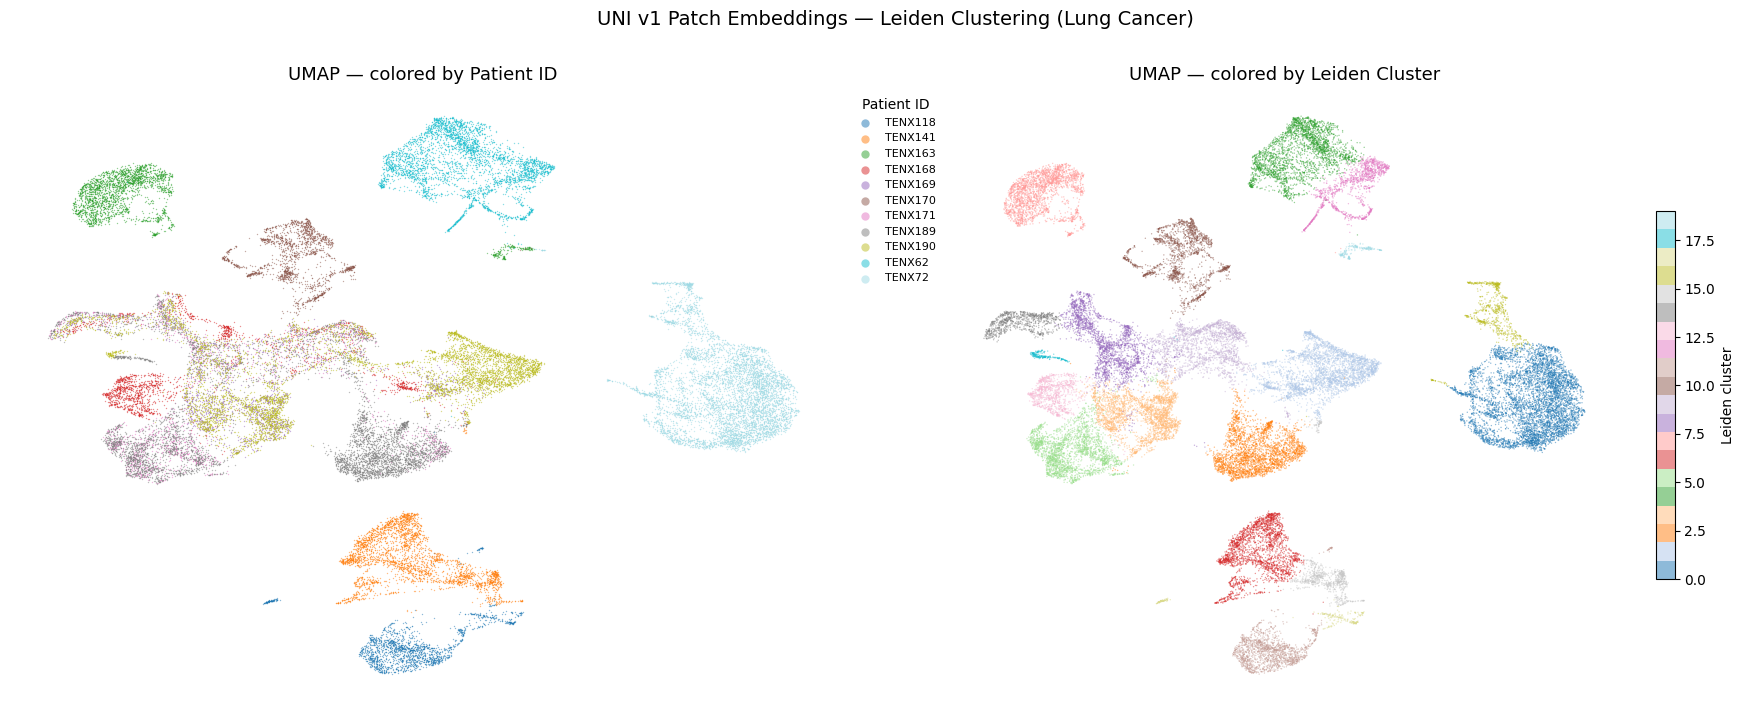

Plot saved to Drive.

=== Patient Mixing per Leiden Cluster ===
leiden  patient_entropy_bits  n_patients_in_cluster  n_patches_total
     0              0.000000                      1             5442
     1              0.734946                      6             3025
     2              0.378018                      4             2768
     3              1.020793                      5             2607
     4              0.000000                      1             2571
     5              0.971861                      5             2432
     6              0.019831                      3             2304
     7              0.005542                      2             2272
     8              2.253339                      5             2152
     9              2.197787                      5             1857
    10              0.000000                      1             1680
    11              0.025907                      2             1550
    12              0.000000           

/tmp/ipykernel_612/2744745694.py:114: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mix_df.groupby("leiden")
/tmp/ipykernel_612/2744745694.py:115: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(cluster_entropy)
/tmp/ipykernel_612/2744745694.py:119: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mix_df.groupby("leiden")[

In [3]:
# ============================================================
# Leiden clustering on pooled UNI v1 embeddings + UMAP viz
# colored by patient ID
# ============================================================

# ---------- 0. Install dependencies ----------
!pip install -q umap-learn leidenalg igraph scanpy

# ---------- 1. Imports ----------
import h5py
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import scanpy as sc
import anndata as ad

# ---------- 2. Load all embeddings from Drive ----------
feat_dir = Path("/content/drive/MyDrive/hest_uni_features")
h5_files = sorted(feat_dir.glob("*_Patches_UNI.h5"))
print(f"Found {len(h5_files)} sample files")

all_feats = []
all_patient_ids = []

for h5_path in h5_files:
    sample_id = h5_path.stem.replace("_Patches_UNI", "")
    with h5py.File(h5_path, "r") as f:
        feats = f["features"][:]           # (N_patches, embed_dim)
    all_feats.append(feats)
    all_patient_ids.extend([sample_id] * len(feats))
    print(f"  {sample_id}: {feats.shape[0]} patches")

X = np.concatenate(all_feats, axis=0)     # (total_patches, embed_dim)
patient_ids = np.array(all_patient_ids)
print(f"\nTotal patches: {X.shape[0]}, Embedding dim: {X.shape[1]}")

# ---------- 3. Build AnnData & run Scanpy Leiden pipeline ----------
adata = ad.AnnData(X=X.astype(np.float32))
adata.obs["patient_id"] = pd.Categorical(patient_ids)

# PCA → kNN graph → Leiden clustering
sc.pp.pca(adata, n_comps=50, svd_solver="arpack")
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=50, metric="cosine")
sc.tl.leiden(adata, resolution=0.5, key_added="leiden")
sc.tl.umap(adata, min_dist=0.3, spread=1.0)

print(f"\nLeiden clusters found: {adata.obs['leiden'].nunique()}")
print(adata.obs["leiden"].value_counts())

# ---------- 4. Plot: UMAP colored by patient ID ----------
n_patients = adata.obs["patient_id"].nunique()
print(f"Unique patients: {n_patients}")

# Build a discrete colormap with enough colors
cmap_base = plt.cm.get_cmap("tab20", n_patients) if n_patients <= 20 else plt.cm.get_cmap("hsv", n_patients)
palette = {pid: mcolors.to_hex(cmap_base(i)) for i, pid in enumerate(adata.obs["patient_id"].cat.categories)}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Panel A: colored by patient ID ---
umap_coords = adata.obsm["X_umap"]
ax = axes[0]
for pid, color in palette.items():
    mask = patient_ids == pid
    ax.scatter(umap_coords[mask, 0], umap_coords[mask, 1],
               c=color, label=pid, s=1, alpha=0.5, linewidths=0)
ax.set_title("UMAP — colored by Patient ID", fontsize=13)
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
ax.axis("off")
# Legend only feasible if few patients
if n_patients <= 20:
    ax.legend(markerscale=6, bbox_to_anchor=(1.01, 1), loc="upper left",
              fontsize=8, frameon=False, title="Patient ID")

# --- Panel B: colored by Leiden cluster ---
leiden_labels = adata.obs["leiden"].values.astype(int)
n_clusters = leiden_labels.max() + 1
cluster_cmap = plt.cm.get_cmap("tab20", n_clusters)
cluster_colors = [cluster_cmap(i) for i in leiden_labels]
sc_b = axes[1].scatter(umap_coords[:, 0], umap_coords[:, 1],
                        c=leiden_labels, cmap="tab20",
                        s=1, alpha=0.5, linewidths=0)
axes[1].set_title("UMAP — colored by Leiden Cluster", fontsize=13)
axes[1].set_xlabel("UMAP 1"); axes[1].set_ylabel("UMAP 2")
axes[1].axis("off")
plt.colorbar(sc_b, ax=axes[1], label="Leiden cluster", shrink=0.6)

plt.suptitle("UNI v1 Patch Embeddings — Leiden Clustering (Lung Cancer)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/hest_uni_features/leiden_umap_patient_colored.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to Drive.")

# ---------- 5. Patient mixing table per cluster ----------
mix_df = (
    adata.obs
    .groupby(["leiden", "patient_id"], observed=True)
    .size()
    .reset_index(name="n_patches")
)

# Entropy of patient distribution per cluster (higher = better mixing)
from scipy.stats import entropy

def cluster_entropy(group):
    counts = group["n_patches"].values
    p = counts / counts.sum()
    return entropy(p, base=2)

entropy_df = (
    mix_df.groupby("leiden")
    .apply(cluster_entropy)
    .reset_index(name="patient_entropy_bits")
)
entropy_df["n_patients_in_cluster"] = (
    mix_df.groupby("leiden")["patient_id"].nunique().values
)
entropy_df["n_patches_total"] = (
    mix_df.groupby("leiden")["n_patches"].sum().values
)

print("\n=== Patient Mixing per Leiden Cluster ===")
print(entropy_df.to_string(index=False))
entropy_df.to_csv("/content/drive/MyDrive/LUNG_leiden_patient_mixing.csv", index=False)
print("\nMixing stats saved.")